# Price Pattern Event Study

This notebook studies post-event price behavior around indicator conditions such as `bollinger_squeeze`.

Workflow:
1. Load daily OHLCV data from the existing `DataAPI`.
2. Build a boolean condition series for the selected pattern.
3. Collapse consecutive true values into distinct events.
4. Expand each event into `[-30, +30]` trading-day windows.
5. Align and normalize price paths, then summarize forward returns and dispersion.

The notebook is intentionally stricter than a naive slice-and-plot flow:
- it deduplicates continuous signals,
- drops incomplete event windows when requested,
- keeps per-event metadata for drill-down,
- compares mean and median paths to reduce outlier bias.


In [11]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from IPython.display import display
from tqdm.auto import tqdm


def find_project_root(start=None):
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "run_backtest.py").exists() and (candidate / "config" / "settings.yaml").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root from the current working directory.")


PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from data.data_api import DataAPI
from signals.indicators import bollinger_bandwidth, bollinger_bands, sma, supertrend

print(f"PROJECT_ROOT = {PROJECT_ROOT}")


PROJECT_ROOT = /Users/chenwei/workspace/2_quant/quant_system


In [ ]:
CONDITION_NAME = "bollinger_squeeze"
START_DATE = "2020-01-01"
END_DATE = "2024-12-31"

SYMBOLS = None      # [000001,000002]
STOCK_FILE = None   # "./data/HS300.txt"
MAX_SYMBOLS = 200
ADJUST_MODE = None  # 'qfq' 'hfq'

WINDOW_BEFORE = 30
WINDOW_AFTER = 30
MIN_GAP_BETWEEN_EVENTS = 20
EVENT_SELECTION = "first_in_run"  # first_in_run | all_true_days
REQUIRE_FULL_WINDOW = True
MIN_DATA_LENGTH = 120

FORWARD_HORIZONS = [1, 5, 10, 20, 30]
SHOW_SAMPLE_PLOTS = 6
EXPORT_RESULTS = True

CONDITION_PARAMS = {
    "window": 20,
    "num_std": 2.0,
    "squeeze_threshold": None,
    "squeeze_quantile": 0.05,
    "squeeze_lookback": 60,
    "require_breakout_confirmation": True,
    "breakout_direction": "up",  # up | down | both
    "breakout_buffer": 0.0,
    "breakout_max_wait": 10,
    "breakout_confirm_bars": 1,
    "use_volume_filter": True,
    "volume_window": 20,
    "volume_multiplier": 1.5,
    "use_trend_filter": True,
    "trend_window": 60,
    "trend_slope_window": 3,
    "use_supertrend_filter": False,
    "supertrend_atr_period": 10,
    "supertrend_multiplier": 3.0,
    "use_band_expansion_filter": True,
    "band_expansion_lookback": 1,
    "use_return_filter": False,
    "min_breakout_return": 0.0,
}


In [23]:
with open(PROJECT_ROOT / "config" / "settings.yaml", "r", encoding="utf-8") as f:
    settings = yaml.safe_load(f)

data_config = settings["data"]
stock_file = STOCK_FILE or data_config.get("stock_file", "./data/HS300.txt")
adjust_mode = data_config.get("adjust_mode", "qfq") if ADJUST_MODE is None else ADJUST_MODE

data_api = DataAPI(
    source=data_config.get("source", "akshare"),
    stock_file=stock_file,
    cache_dir=data_config.get("cache_dir", "./data/raw"),
    processed_dir=data_config.get("processed_dir", "./data/processed"),
    adjust_mode=adjust_mode,
)

symbols = list(SYMBOLS) if SYMBOLS is not None else data_api.get_stock_list()
if MAX_SYMBOLS is not None and MAX_SYMBOLS > 0:
    symbols = symbols[:MAX_SYMBOLS]

runtime_summary = pd.Series(
    {
        "condition_name": CONDITION_NAME,
        "start_date": START_DATE,
        "end_date": END_DATE,
        "stock_file": stock_file,
        "symbol_count": len(symbols),
        "adjust_mode": data_api.adjust_mode_label,
        "window_before": WINDOW_BEFORE,
        "window_after": WINDOW_AFTER,
        "min_gap_between_events": MIN_GAP_BETWEEN_EVENTS,
        "event_selection": EVENT_SELECTION,
        "require_full_window": REQUIRE_FULL_WINDOW,
        "require_breakout_confirmation": CONDITION_PARAMS.get("require_breakout_confirmation", False),
        "breakout_direction": CONDITION_PARAMS.get("breakout_direction", "both"),
    }
)
display(runtime_summary.to_frame("value"))


,value
condition_name,bollinger_squeeze
start_date,2020-01-01
end_date,2024-12-31
stock_file,./data/HS300.txt
symbol_count,200
adjust_mode,qfq
window_before,30
window_after,30
min_gap_between_events,20
event_selection,first_in_run


In [24]:
STANDARD_PRICE_COLUMNS = [
    "date",
    "code",
    "open",
    "close",
    "high",
    "low",
    "volume",
    "amount",
    "amplitude",
    "pct_change",
    "change",
    "turnover",
]


def standardize_price_frame(raw_df):
    if raw_df is None or raw_df.empty:
        return pd.DataFrame()

    df = raw_df.copy()

    if len(df.columns) == 13:
        df.columns = ["index", *STANDARD_PRICE_COLUMNS]
    elif len(df.columns) == 12:
        df.columns = STANDARD_PRICE_COLUMNS

    rename_map = {}
    for column in df.columns:
        name = str(column).strip().lower()
        if name in {"date", "datetime", "日期"}:
            rename_map[column] = "date"
        elif name in {"open", "开盘"}:
            rename_map[column] = "open"
        elif name in {"close", "收盘"}:
            rename_map[column] = "close"
        elif name in {"high", "最高"}:
            rename_map[column] = "high"
        elif name in {"low", "最低"}:
            rename_map[column] = "low"
        elif name in {"volume", "vol", "成交量"}:
            rename_map[column] = "volume"
        elif name in {"code", "symbol", "股票代码"}:
            rename_map[column] = "code"

    df = df.rename(columns=rename_map)

    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"])
        df = df.set_index("date")
    else:
        df.index = pd.to_datetime(df.index)

    for column in ["open", "high", "low", "close", "volume", "amount"]:
        if column in df.columns:
            df[column] = pd.to_numeric(df[column], errors="coerce")

    df = df.sort_index()
    df = df[~df.index.duplicated(keep="last")]
    return df


def build_bollinger_squeeze_condition(df, params):
    prices = df["close"]
    window = params.get("window", 20)
    num_std = params.get("num_std", 2.0)
    upper_band, middle_band, lower_band = bollinger_bands(prices, window=window, num_std=num_std)
    bandwidth = (upper_band - lower_band) / middle_band.replace(0, np.nan)

    squeeze_threshold = params.get("squeeze_threshold")
    if squeeze_threshold is None:
        threshold = bandwidth.rolling(
            window=params.get("squeeze_lookback", 60),
            min_periods=max(window, 5),
        ).quantile(params.get("squeeze_quantile", 0.1))
    else:
        threshold = pd.Series(squeeze_threshold, index=df.index, dtype=float)

    squeeze_condition = (bandwidth <= threshold).fillna(False)
    require_breakout_confirmation = params.get("require_breakout_confirmation", False)
    breakout_direction = params.get("breakout_direction", "both")
    if breakout_direction not in {"up", "down", "both"}:
        raise ValueError("breakout_direction must be one of: up, down, both")

    breakout_buffer = float(params.get("breakout_buffer", 0.0))
    breakout_max_wait = max(int(params.get("breakout_max_wait", 10)), 1)
    breakout_confirm_bars = max(int(params.get("breakout_confirm_bars", 1)), 1)

    volume_confirmation = pd.Series(True, index=df.index, dtype=bool)
    if params.get("use_volume_filter", False):
        if "volume" not in df.columns:
            raise ValueError("volume column is required when use_volume_filter=True")
        volume_window = int(params.get("volume_window", 20))
        volume_multiplier = float(params.get("volume_multiplier", 1.5))
        volume_ma = sma(df["volume"], volume_window)
        volume_confirmation = ((df["volume"] >= volume_ma * volume_multiplier) & (df["volume"] > df["volume"].shift(1))).fillna(False)

    trend_long_confirmation = pd.Series(True, index=df.index, dtype=bool)
    trend_short_confirmation = pd.Series(True, index=df.index, dtype=bool)
    if params.get("use_trend_filter", False):
        trend_window = int(params.get("trend_window", 60))
        trend_slope_window = int(params.get("trend_slope_window", 3))
        trend_ma = sma(prices, trend_window)
        trend_long_confirmation = ((prices > trend_ma) & (trend_ma > trend_ma.shift(trend_slope_window))).fillna(False)
        trend_short_confirmation = ((prices < trend_ma) & (trend_ma < trend_ma.shift(trend_slope_window))).fillna(False)

    supertrend_long_confirmation = pd.Series(True, index=df.index, dtype=bool)
    supertrend_short_confirmation = pd.Series(True, index=df.index, dtype=bool)
    if params.get("use_supertrend_filter", False):
        required_columns = {"high", "low", "close"}
        if not required_columns.issubset(df.columns):
            raise ValueError("high, low, close columns are required when use_supertrend_filter=True")
        _, trend_direction = supertrend(
            df["high"],
            df["low"],
            prices,
            atr_period=int(params.get("supertrend_atr_period", 10)),
            multiplier=float(params.get("supertrend_multiplier", 3.0)),
        )
        supertrend_long_confirmation = (trend_direction > 0).fillna(False)
        supertrend_short_confirmation = (trend_direction < 0).fillna(False)

    band_expansion_confirmation = pd.Series(True, index=df.index, dtype=bool)
    if params.get("use_band_expansion_filter", False):
        band_expansion_lookback = max(int(params.get("band_expansion_lookback", 1)), 1)
        band_expansion_confirmation = (bandwidth > bandwidth.shift(band_expansion_lookback)).fillna(False)

    return_up_confirmation = pd.Series(True, index=df.index, dtype=bool)
    return_down_confirmation = pd.Series(True, index=df.index, dtype=bool)
    if params.get("use_return_filter", False):
        min_breakout_return = float(params.get("min_breakout_return", 0.0))
        daily_return = prices.pct_change()
        return_up_confirmation = (daily_return >= min_breakout_return).fillna(False)
        return_down_confirmation = (daily_return <= -min_breakout_return).fillna(False)

    breakout_up = pd.Series(False, index=df.index, dtype=bool)
    breakout_down = pd.Series(False, index=df.index, dtype=bool)
    breakout_valid = pd.Series(False, index=df.index, dtype=bool)
    event_direction = pd.Series(index=df.index, dtype=object)
    condition = squeeze_condition.copy() if not require_breakout_confirmation else pd.Series(False, index=df.index, dtype=bool)

    if require_breakout_confirmation:
        in_squeeze = False
        bars_since_squeeze = 0
        up_streak = 0
        down_streak = 0

        for i in range(len(df)):
            if pd.isna(bandwidth.iloc[i]) or pd.isna(threshold.iloc[i]) or pd.isna(upper_band.iloc[i]) or pd.isna(lower_band.iloc[i]):
                continue

            if squeeze_condition.iloc[i]:
                in_squeeze = True
                bars_since_squeeze = 0
                up_streak = 0
                down_streak = 0
                continue

            if not in_squeeze:
                continue

            bars_since_squeeze += 1
            if bars_since_squeeze > breakout_max_wait:
                in_squeeze = False
                up_streak = 0
                down_streak = 0
                continue

            close_above_upper = prices.iloc[i] > upper_band.iloc[i] * (1 + breakout_buffer)
            close_below_lower = prices.iloc[i] < lower_band.iloc[i] * (1 - breakout_buffer)
            up_streak = up_streak + 1 if close_above_upper else 0
            down_streak = down_streak + 1 if close_below_lower else 0

            breakout_up.iloc[i] = up_streak >= breakout_confirm_bars
            breakout_down.iloc[i] = down_streak >= breakout_confirm_bars

            long_filters_ok = (
                volume_confirmation.iloc[i]
                and trend_long_confirmation.iloc[i]
                and supertrend_long_confirmation.iloc[i]
                and band_expansion_confirmation.iloc[i]
                and return_up_confirmation.iloc[i]
            )
            short_filters_ok = (
                volume_confirmation.iloc[i]
                and trend_short_confirmation.iloc[i]
                and supertrend_short_confirmation.iloc[i]
                and band_expansion_confirmation.iloc[i]
                and return_down_confirmation.iloc[i]
            )

            if breakout_direction in {"up", "both"} and breakout_up.iloc[i] and long_filters_ok:
                breakout_valid.iloc[i] = True
                event_direction.iloc[i] = "up"
                condition.iloc[i] = True
                in_squeeze = False
                up_streak = 0
                down_streak = 0
            elif breakout_direction in {"down", "both"} and breakout_down.iloc[i] and short_filters_ok:
                breakout_valid.iloc[i] = True
                event_direction.iloc[i] = "down"
                condition.iloc[i] = True
                in_squeeze = False
                up_streak = 0
                down_streak = 0

    return pd.DataFrame(
        {
            "upper_band": upper_band,
            "middle_band": middle_band,
            "lower_band": lower_band,
            "bandwidth": bandwidth,
            "condition_threshold": threshold,
            "squeeze_condition": squeeze_condition,
            "breakout_up": breakout_up,
            "breakout_down": breakout_down,
            "breakout_valid": breakout_valid,
            "event_direction": event_direction,
            "volume_confirmation": volume_confirmation,
            "trend_long_confirmation": trend_long_confirmation,
            "trend_short_confirmation": trend_short_confirmation,
            "supertrend_long_confirmation": supertrend_long_confirmation,
            "supertrend_short_confirmation": supertrend_short_confirmation,
            "band_expansion_confirmation": band_expansion_confirmation,
            "return_up_confirmation": return_up_confirmation,
            "return_down_confirmation": return_down_confirmation,
            "condition": condition,
        },
        index=df.index,
    )


CONDITION_BUILDERS = {
    "bollinger_squeeze": build_bollinger_squeeze_condition,
}


def build_condition_frame(df, condition_name, params):
    if condition_name not in CONDITION_BUILDERS:
        raise ValueError(f"Unsupported condition: {condition_name}")
    return CONDITION_BUILDERS[condition_name](df, params)


def extract_event_dates(condition, min_gap_between_events=0, event_selection="first_in_run"):
    condition = condition.fillna(False).astype(bool)

    if event_selection == "all_true_days":
        candidate_dates = list(condition[condition].index)
    else:
        previous_condition = condition.shift(1, fill_value=False)
        run_starts = condition & (~previous_condition)
        candidate_dates = list(run_starts[run_starts].index)

    if min_gap_between_events <= 0:
        return candidate_dates

    index_lookup = {timestamp: i for i, timestamp in enumerate(condition.index)}
    selected_dates = []
    last_position = None

    for event_date in candidate_dates:
        current_position = index_lookup[event_date]
        if last_position is None or current_position - last_position >= min_gap_between_events:
            selected_dates.append(event_date)
            last_position = current_position

    return selected_dates


def build_event_window(df, symbol, event_date, window_before, window_after, require_full_window=True):
    event_position = df.index.get_loc(event_date)
    start_position = event_position - window_before
    end_position = event_position + window_after

    if require_full_window and (start_position < 0 or end_position >= len(df)):
        return None

    start_position = max(start_position, 0)
    end_position = min(end_position, len(df) - 1)
    window = df.iloc[start_position : end_position + 1].copy()

    if window.empty:
        return None

    event_close = float(df.loc[event_date, "close"])
    if pd.isna(event_close) or event_close <= 0:
        return None

    relative_days = np.arange(start_position - event_position, end_position - event_position + 1)
    window["relative_day"] = relative_days
    window["symbol"] = symbol
    window["event_date"] = pd.Timestamp(event_date)
    window["event_close"] = event_close
    window["close_to_event"] = window["close"] / event_close - 1.0
    return window.reset_index().rename(columns={window.index.name or "index": "trade_date"})


In [25]:
event_windows = []
event_rows = []
skip_rows = []

for symbol in tqdm(symbols, desc="Scanning symbols", unit="symbol"):
    try:
        raw_df = data_api.get_price_history_data(symbol, START_DATE, END_DATE)
        price_df = standardize_price_frame(raw_df)

        required_columns = {"close", "high", "low", "volume"}
        if price_df.empty:
            skip_rows.append({"symbol": symbol, "reason": "empty_price_data"})
            continue
        if len(price_df) < MIN_DATA_LENGTH:
            skip_rows.append({"symbol": symbol, "reason": "insufficient_history"})
            continue
        if not required_columns.issubset(price_df.columns):
            skip_rows.append({"symbol": symbol, "reason": "missing_required_columns"})
            continue

        condition_frame = build_condition_frame(price_df, CONDITION_NAME, CONDITION_PARAMS)
        analysis_df = price_df.join(condition_frame)
        analysis_df = analysis_df.dropna(subset=["close"])

        event_dates = extract_event_dates(
            analysis_df["condition"],
            min_gap_between_events=MIN_GAP_BETWEEN_EVENTS,
            event_selection=EVENT_SELECTION,
        )

        if not event_dates:
            skip_rows.append({"symbol": symbol, "reason": "no_events"})
            continue

        for event_date in event_dates:
            window_df = build_event_window(
                analysis_df,
                symbol=symbol,
                event_date=event_date,
                window_before=WINDOW_BEFORE,
                window_after=WINDOW_AFTER,
                require_full_window=REQUIRE_FULL_WINDOW,
            )

            if window_df is None:
                continue

            event_windows.append(window_df)
            event_rows.append(
                {
                    "symbol": symbol,
                    "event_date": pd.Timestamp(event_date),
                    "event_close": float(analysis_df.loc[event_date, "close"]),
                    "bandwidth": float(analysis_df.loc[event_date, "bandwidth"]),
                    "condition_threshold": float(analysis_df.loc[event_date, "condition_threshold"]),
                    "event_direction": analysis_df.loc[event_date, "event_direction"] if "event_direction" in analysis_df.columns else None,
                    "breakout_valid": bool(analysis_df.loc[event_date, "breakout_valid"]) if "breakout_valid" in analysis_df.columns else None,
                    "volume_confirmation": bool(analysis_df.loc[event_date, "volume_confirmation"]) if "volume_confirmation" in analysis_df.columns else None,
                    "trend_long_confirmation": bool(analysis_df.loc[event_date, "trend_long_confirmation"]) if "trend_long_confirmation" in analysis_df.columns else None,
                    "trend_short_confirmation": bool(analysis_df.loc[event_date, "trend_short_confirmation"]) if "trend_short_confirmation" in analysis_df.columns else None,
                    "band_expansion_confirmation": bool(analysis_df.loc[event_date, "band_expansion_confirmation"]) if "band_expansion_confirmation" in analysis_df.columns else None,
                }
            )
    except Exception as exc:
        skip_rows.append({"symbol": symbol, "reason": type(exc).__name__, "detail": str(exc)})

event_meta = pd.DataFrame(event_rows).sort_values(["event_date", "symbol"]).reset_index(drop=True)
event_window_df = pd.concat(event_windows, ignore_index=True) if event_windows else pd.DataFrame()
skip_df = pd.DataFrame(skip_rows)

print(f"Event count: {len(event_meta)}")
print(f"Skipped symbols: {len(skip_df)}")
display(event_meta.head(10))
display(skip_df.head(10))


Scanning symbols:   0%|          | 0/200 [00:00<?, ?symbol/s]

Event count: 768
Skipped symbols: 2


,symbol,event_date,event_close,bandwidth,condition_threshold,event_direction,breakout_valid,volume_confirmation,trend_long_confirmation,trend_short_confirmation,band_expansion_confirmation
0,601066,2020-04-16,34.59,0.195207,0.130477,up,True,True,True,False,True
1,601698,2020-04-21,18.93,0.327430,0.247207,up,True,True,True,False,True
2,600570,2020-04-27,41.65,0.153519,0.111365,up,True,True,True,False,True
3,300496,2020-04-30,60.76,0.176208,0.152426,up,True,True,True,False,True
4,600600,2020-04-30,46.55,0.194062,0.104147,up,True,True,True,False,True
5,600655,2020-04-30,6.09,0.073582,0.073295,up,True,True,True,False,True
6,600584,2020-05-06,26.68,0.297490,0.179699,up,True,True,True,False,True
7,603019,2020-05-06,36.00,0.161750,0.141518,up,True,True,True,False,True
8,603501,2020-05-06,154.02,0.314773,0.189676,up,True,True,True,False,True
9,688008,2020-05-06,104.00,0.273213,0.204091,up,True,True,True,False,True


,symbol,reason
0,603799,no_events
1,600383,no_events


In [26]:
event_windows = []
event_rows = []
skip_rows = []

for symbol in tqdm(symbols, desc="Scanning symbols", unit="symbol"):
    try:
        raw_df = data_api.get_price_history_data(symbol, START_DATE, END_DATE)
        price_df = standardize_price_frame(raw_df)

        required_columns = {"close", "high", "low", "volume"}
        if price_df.empty:
            skip_rows.append({"symbol": symbol, "reason": "empty_price_data"})
            continue
        if len(price_df) < MIN_DATA_LENGTH:
            skip_rows.append({"symbol": symbol, "reason": "insufficient_history"})
            continue
        if not required_columns.issubset(price_df.columns):
            skip_rows.append({"symbol": symbol, "reason": "missing_required_columns"})
            continue

        condition_frame = build_condition_frame(price_df, CONDITION_NAME, CONDITION_PARAMS)
        analysis_df = price_df.join(condition_frame)
        analysis_df = analysis_df.dropna(subset=["close"])

        event_dates = extract_event_dates(
            analysis_df["condition"],
            min_gap_between_events=MIN_GAP_BETWEEN_EVENTS,
            event_selection=EVENT_SELECTION,
        )

        if not event_dates:
            skip_rows.append({"symbol": symbol, "reason": "no_events"})
            continue

        for event_date in event_dates:
            window_df = build_event_window(
                analysis_df,
                symbol=symbol,
                event_date=event_date,
                window_before=WINDOW_BEFORE,
                window_after=WINDOW_AFTER,
                require_full_window=REQUIRE_FULL_WINDOW,
            )

            if window_df is None:
                continue

            event_windows.append(window_df)
            event_rows.append(
                {
                    "symbol": symbol,
                    "event_date": pd.Timestamp(event_date),
                    "event_close": float(analysis_df.loc[event_date, "close"]),
                    "bandwidth": float(analysis_df.loc[event_date, "bandwidth"]),
                    "condition_threshold": float(analysis_df.loc[event_date, "condition_threshold"]),
                }
            )
    except Exception as exc:
        skip_rows.append({"symbol": symbol, "reason": type(exc).__name__, "detail": str(exc)})

event_meta = pd.DataFrame(event_rows).sort_values(["event_date", "symbol"]).reset_index(drop=True)
event_window_df = pd.concat(event_windows, ignore_index=True) if event_windows else pd.DataFrame()
skip_df = pd.DataFrame(skip_rows)

print(f"Event count: {len(event_meta)}")
print(f"Skipped symbols: {len(skip_df)}")
display(event_meta.head(10))
display(skip_df.head(10))


Scanning symbols:   0%|          | 0/200 [00:00<?, ?symbol/s]

Event count: 768
Skipped symbols: 2


,symbol,event_date,event_close,bandwidth,condition_threshold
0,601066,2020-04-16,34.59,0.195207,0.130477
1,601698,2020-04-21,18.93,0.327430,0.247207
2,600570,2020-04-27,41.65,0.153519,0.111365
3,300496,2020-04-30,60.76,0.176208,0.152426
4,600600,2020-04-30,46.55,0.194062,0.104147
5,600655,2020-04-30,6.09,0.073582,0.073295
6,600584,2020-05-06,26.68,0.297490,0.179699
7,603019,2020-05-06,36.00,0.161750,0.141518
8,603501,2020-05-06,154.02,0.314773,0.189676
9,688008,2020-05-06,104.00,0.273213,0.204091


,symbol,reason
0,603799,no_events
1,600383,no_events


,horizon,sample_count,mean_return,median_return,win_rate,p25,p75
0,1,768,0.005682,-0.000465,0.459635,-0.013150,0.016366
1,5,768,0.014703,0.000000,0.498698,-0.030964,0.040730
2,10,768,0.020886,0.006098,0.523438,-0.040209,0.057746
3,20,768,0.035271,0.007435,0.526042,-0.058457,0.090978
4,30,768,0.049501,-0.001659,0.489583,-0.071686,0.107654


,event_count
symbol,
603501,9
600029,8
600031,8
601111,8
601857,8
688169,8
300750,7
601668,7
600219,7


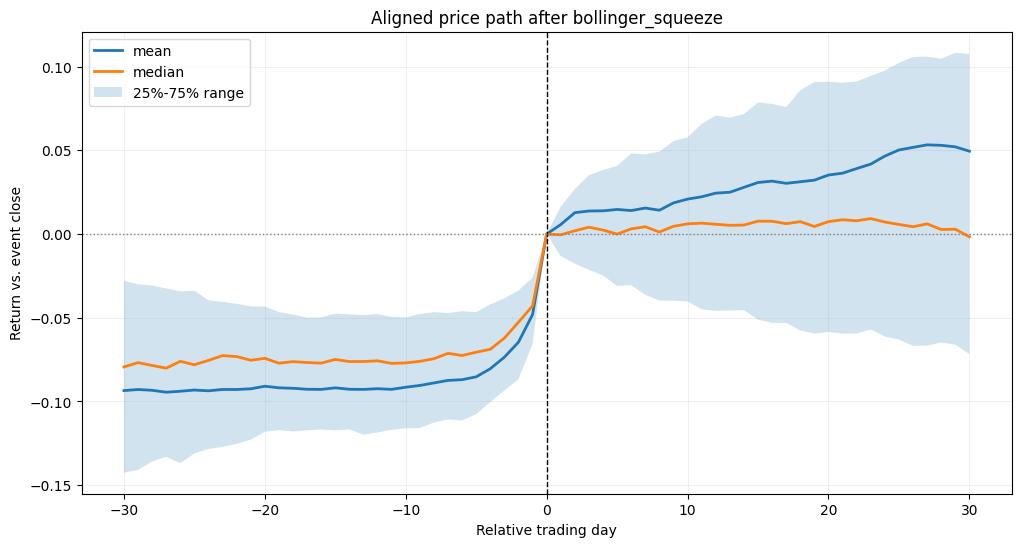

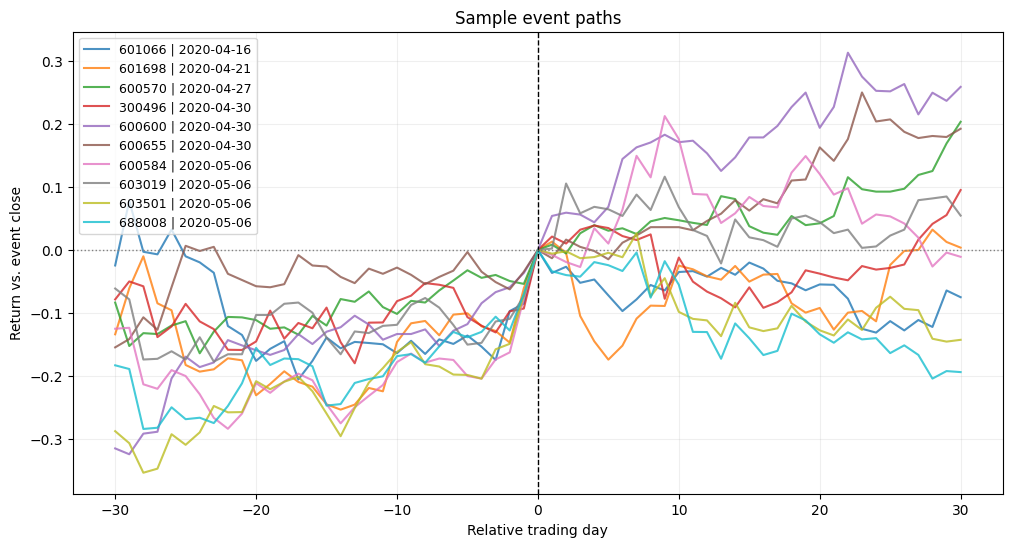

In [27]:
if event_meta.empty:
    raise ValueError("No event windows were collected. Adjust the universe, dates, or condition parameters.")

path_matrix = (
    event_window_df
    .pivot_table(index=["symbol", "event_date"], columns="relative_day", values="close_to_event")
    .sort_index(axis=1)
)

forward_rows = []
for horizon in FORWARD_HORIZONS:
    if horizon not in path_matrix.columns:
        continue

    values = path_matrix[horizon].dropna()
    if values.empty:
        continue

    forward_rows.append(
        {
            "horizon": horizon,
            "sample_count": int(values.shape[0]),
            "mean_return": float(values.mean()),
            "median_return": float(values.median()),
            "win_rate": float((values > 0).mean()),
            "p25": float(values.quantile(0.25)),
            "p75": float(values.quantile(0.75)),
        }
    )

forward_summary = pd.DataFrame(forward_rows)
event_count_by_symbol = event_meta.groupby("symbol").size().sort_values(ascending=False).rename("event_count")

display(forward_summary)
display(event_count_by_symbol.head(20).to_frame())

x = path_matrix.columns.to_numpy(dtype=int)
mean_path = path_matrix.mean(axis=0)
median_path = path_matrix.median(axis=0)
p25 = path_matrix.quantile(0.25, axis=0)
p75 = path_matrix.quantile(0.75, axis=0)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(x, mean_path.values, label="mean", linewidth=2)
ax.plot(x, median_path.values, label="median", linewidth=2)
ax.fill_between(x, p25.values, p75.values, alpha=0.2, label="25%-75% range")
ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.axhline(0, color="grey", linestyle=":", linewidth=1)
ax.set_title(f"Aligned price path after {CONDITION_NAME}")
ax.set_xlabel("Relative trading day")
ax.set_ylabel("Return vs. event close")
ax.legend()
ax.grid(alpha=0.2)
plt.show()

sample_events = event_meta.head(SHOW_SAMPLE_PLOTS)
if not sample_events.empty:
    fig, ax = plt.subplots(figsize=(12, 6))
    for row in sample_events.itertuples(index=False):
        sample_path = path_matrix.loc[(row.symbol, row.event_date)]
        ax.plot(sample_path.index.to_numpy(dtype=int), sample_path.values, alpha=0.8, label=f"{row.symbol} | {row.event_date:%Y-%m-%d}")
    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    ax.axhline(0, color="grey", linestyle=":", linewidth=1)
    ax.set_title("Sample event paths")
    ax.set_xlabel("Relative trading day")
    ax.set_ylabel("Return vs. event close")
    ax.grid(alpha=0.2)
    ax.legend(loc="best", fontsize=9)
    plt.show()


In [28]:
if EXPORT_RESULTS:
    output_dir = PROJECT_ROOT / "output" / "pattern_event_study"
    output_dir.mkdir(parents=True, exist_ok=True)

    suffix = f"{CONDITION_NAME}_{START_DATE}_{END_DATE}".replace(":", "-")
    event_meta.to_csv(output_dir / f"event_meta_{suffix}.csv", index=False, encoding="utf-8-sig")
    event_window_df.to_csv(output_dir / f"event_windows_{suffix}.csv", index=False, encoding="utf-8-sig")
    forward_summary.to_csv(output_dir / f"forward_summary_{suffix}.csv", index=False, encoding="utf-8-sig")
    print(f"Exported results to: {output_dir}")


## What is worth extending next

The current notebook is a good baseline for event studies, but the next upgrades usually matter most:

- Compare `first_in_run` against breakout-style event definitions instead of counting every squeeze day.
- Split results by market regime, index trend, or volume expansion to avoid mixing very different environments.
- Add benchmark-relative returns so the path is not dominated by market beta.
- Export a per-event label set for later modeling, ranking, or manual chart review.
- Extend `CONDITION_BUILDERS` when you want to study other patterns with the same windowing pipeline.
